# Uncertainty Quantification

### 1. Loading Model

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
from tqdm import tqdm
import sys
import os

# --- 设置项目路径 ---
# 确保可以导入我们自己写的模块 (src目录下的文件)
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# --- 从我们自己的模块中导入 ---
from src import config
from src.dataset import create_data_loader
from src.model import SentimentClassifier
from transformers import DistilBertTokenizer

# --- 加载模型 ---
print("正在加载最佳基线模型...")
device = torch.device(config.DEVICE)
model = SentimentClassifier(n_classes=config.N_CLASSES)
model_path = f"{config.SAVED_MODELS_PATH}/{config.SAVED_MODELS_NAME}"

# 加载已保存的状态字典
# 使用 map_location=device 确保模型被加载到正确的设备上
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval() # 切换到评估模式

# --- 加载分词器 ---
tokenizer = DistilBertTokenizer.from_pretrained(config.MODEL_NAME)
print("模型和分词器加载成功！")

正在加载最佳基线模型...
模型和分词器加载成功！


### 2. Calculate the Optimal Temperature T Value

In [ ]:
from src.uncertainty.temperature_scaling import find_optimal_temperature, apply_temperature

# --- 准备验证集数据 ---
val_data_loader = create_data_loader(
    f"{config.PROCESSED_DATA_PATH}/validation.csv",
    tokenizer,
    config.MAX_LEN,
    config.BATCH_SIZE
)

# 1. 找到最优T
optimal_temperature = find_optimal_temperature(model, val_data_loader, device)
print(f"优化完成！最佳温度 T = {optimal_temperature:.4f}")

Finding Optimal T: 100%|██████████| 156/156 [00:33<00:00,  4.62it/s]


优化完成！最佳温度 T = 1.2871


### 3. Evaluate Calibration Effectiveness on the Test Set

In [ ]:
# --- 准备测试集数据 ---
test_data_loader = create_data_loader(
    f"{config.PROCESSED_DATA_PATH}/test.csv",
    tokenizer,
    config.MAX_LEN,
    config.BATCH_SIZE
)

# --- 在测试集上获取Logits和概率 ---
test_logits = []
test_labels = []
with torch.no_grad():
    for d in tqdm(test_data_loader, desc="Testing"):
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)
        
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        test_logits.append(logits)
        test_labels.append(labels)

test_logits = torch.cat(test_logits)
test_labels = torch.cat(test_labels)

# --- 计算校准前后的概率和置信度 ---
softmaxes = torch.softmax(test_logits, dim=1)
confidences, predictions = torch.max(softmaxes, 1)

# 使用最优温度进行校准
scaled_logits = test_logits / optimal_temperature
calibrated_softmaxes = torch.softmax(scaled_logits, dim=1)
calibrated_confidences, _ = torch.max(calibrated_softmaxes, 1)

# --- 打印结果对比 ---
print("\n--- 校准效果对比 ---")
print(f"校准前 (T=1.0) 的平均置信度: {confidences.mean().item():.4f}")
print(f"校准后 (T={optimal_temperature:.4f}) 的平均置信度: {calibrated_confidences.mean().item():.4f}")

# --- 计算准确率和F1分数 ---
accuracy = (predictions == test_labels).float().mean()

# --- 新增代码：计算加权F1分数 ---
# scikit-learn的函数需要NumPy数组，所以我们用 .cpu().numpy() 进行转换
y_true = test_labels.cpu().numpy()
y_pred = predictions.cpu().numpy()
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
# ---------------------------------

print("\n--- 最终性能评估 ---")
print(f"模型在测试集上的准确率: {accuracy.item():.4f} (此值不应受温度影响)")
# --- 新增代码：打印F1分数 ---
print(f"模型在测试集上的加权F1分数: {weighted_f1:.4f} (此值不应受温度影响)")

Testing: 100%|██████████| 156/156 [00:33<00:00,  4.66it/s]



--- 校准效果对比 ---
校准前 (T=1.0) 的平均置信度: 0.8768
校准后 (T=1.2871) 的平均置信度: 0.8410

--- 最终性能评估 ---
模型在测试集上的准确率: 0.8165 (此值不应受温度影响)
模型在测试集上的加权F1分数: 0.8165 (此值不应受温度影响)


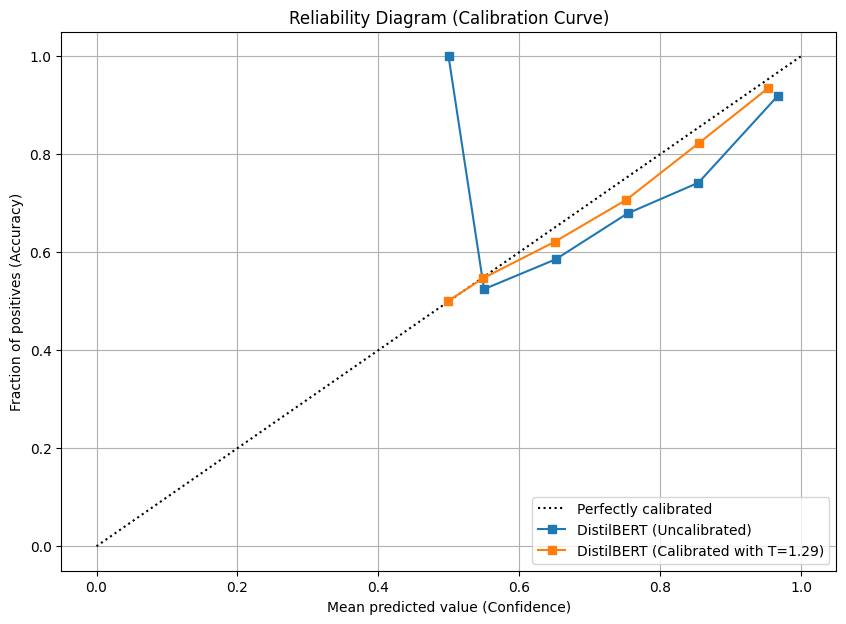

In [7]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# --- 准备绘图所需的数据 ---
# 我们需要每个类别的概率，而不是只看最大置信度
# y_true 已经在上个单元格中从 test_labels 转换得到
# y_pred 也已经从 predictions 转换得到

# 校准前的概率 (取预测类别的概率)
prob_before = confidences.cpu().numpy()
# 校准后的概率
prob_after = calibrated_confidences.cpu().numpy()

# --- 计算校准曲线的点 ---
# uncalibrated
fraction_of_positives_before, mean_predicted_value_before = \
    calibration_curve(y_true == y_pred, prob_before, n_bins=10)

# calibrated
fraction_of_positives_after, mean_predicted_value_after = \
    calibration_curve(y_true == y_pred, prob_after, n_bins=10)

# --- 开始绘图 ---
plt.figure(figsize=(10, 7))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated") # 完美的对角线

# 绘制校准前的曲线
plt.plot(mean_predicted_value_before, fraction_of_positives_before, "s-",
         label="%s (Uncalibrated)" % "DistilBERT")

# 绘制校准后的曲线
plt.plot(mean_predicted_value_after, fraction_of_positives_after, "s-",
         label="%s (Calibrated with T=%.2f)" % ("DistilBERT", optimal_temperature))

plt.ylabel("Fraction of positives (Accuracy)")
plt.xlabel("Mean predicted value (Confidence)")
plt.ylim([-0.05, 1.05])
plt.legend(loc="lower right")
plt.title('Reliability Diagram (Calibration Curve)')
plt.grid(True)
plt.show()

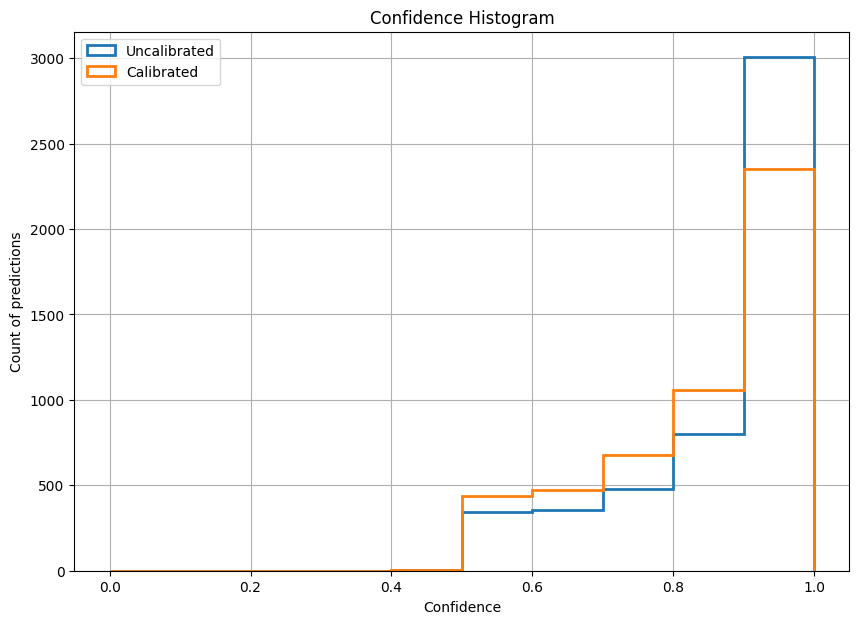

In [8]:
plt.figure(figsize=(10, 7))

# 绘制校准前的置信度直方图
plt.hist(prob_before, range=(0, 1), bins=10, label="Uncalibrated",
         histtype="step", lw=2)

# 绘制校准后的置信度直方图
plt.hist(prob_after, range=(0, 1), bins=10, label="Calibrated",
         histtype="step", lw=2)

plt.xlabel("Confidence")
plt.ylabel("Count of predictions")
plt.title("Confidence Histogram")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

/var/folders/00/4sv93fnd3yz1qvh8ds_7yfz80000gn/T/ipykernel_39846/1486889909.py:64: UserWarning: Glyph 35206 (\N{CJK UNIFIED IDEOGRAPH-8986}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 调整子图间距
/var/folders/00/4sv93fnd3yz1qvh8ds_7yfz80000gn/T/ipykernel_39846/1486889909.py:64: UserWarning: Glyph 30422 (\N{CJK UNIFIED IDEOGRAPH-76D6}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 调整子图间距
/var/folders/00/4sv93fnd3yz1qvh8ds_7yfz80000gn/T/ipykernel_39846/1486889909.py:64: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 调整子图间距


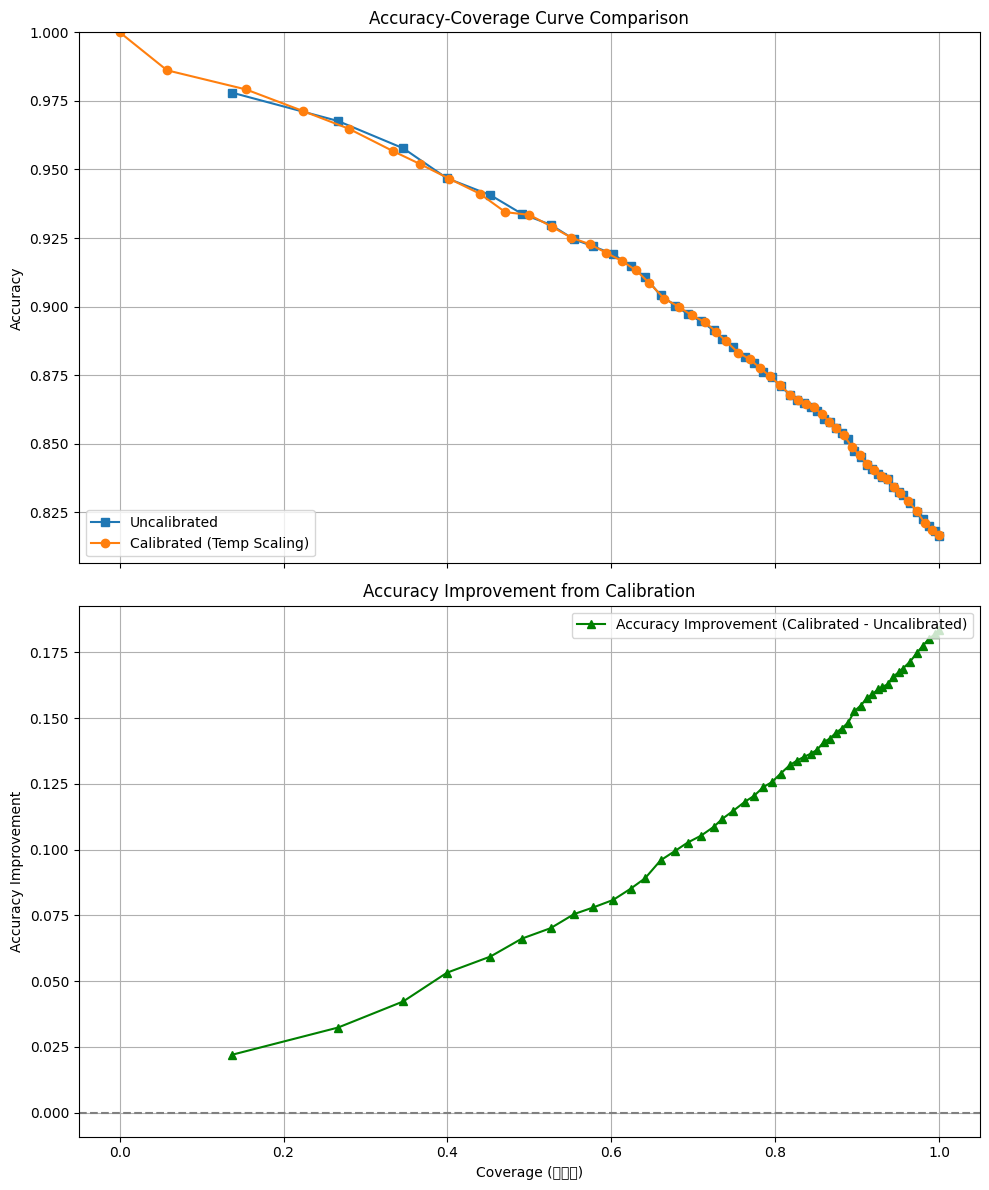

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ... (上面的 calculate_accuracy_coverage_curve 函数和数据计算部分保持不变) ...
# --- 计算曲线数据的函数 (保持不变) ---
def calculate_accuracy_coverage_curve(probabilities, labels):
    confidences, predictions = torch.max(probabilities, 1)
    thresholds = np.arange(0.5, 1.0, 0.01)
    coverages = []
    accuracies = []
    for threshold in thresholds:
        mask = confidences > threshold
        if mask.sum() == 0:
            coverages.append(0)
            accuracies.append(1) 
            continue
        coverage = mask.float().mean().item()
        correct_predictions = (predictions[mask] == labels[mask]).float().sum()
        accuracy = (correct_predictions / mask.sum()).item()
        coverages.append(coverage)
        accuracies.append(accuracy)
    return coverages, accuracies

# --- 计算数据 (保持不变) ---
uncal_coverages, uncal_accuracies = calculate_accuracy_coverage_curve(softmaxes, test_labels)
cal_coverages, cal_accuracies = calculate_accuracy_coverage_curve(calibrated_softmaxes, test_labels)

# --- 新增代码：计算准确率差异 ---
# 因为两条曲线的x轴(coverages)不完全对齐，我们需要先进行插值
# 以"Uncalibrated"的覆盖率作为统一的x轴
common_coverage_x = np.array(uncal_coverages)

# 使用线性插值，计算在这些x点上，"Calibrated"曲线对应的y值
cal_accuracies_interp = np.interp(common_coverage_x, cal_coverages, cal_accuracies)

# 计算准确率的提升量
accuracy_improvement = cal_accuracies_interp - np.array(uncal_accuracies)
# ----------------------------------


# --- 绘制两张图：一张是对比图，一张是差异图 ---
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True) # 创建上下两个子图

# --- 子图1：原始的准确率-覆盖率对比图 (Zoomed In) ---
axes[0].plot(uncal_coverages, uncal_accuracies, "s-", label="Uncalibrated")
axes[0].plot(cal_coverages, cal_accuracies, "o-", label="Calibrated (Temp Scaling)")
min_accuracy = min(min(uncal_accuracies), min(cal_accuracies))
axes[0].set_ylim([min_accuracy - 0.01, 1.0])
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy-Coverage Curve Comparison")
axes[0].grid(True)
axes[0].legend(loc="lower left")

# --- 子图2：准确率提升差异图 ---
axes[1].plot(common_coverage_x, accuracy_improvement, 'g-^', label='Accuracy Improvement (Calibrated - Uncalibrated)')
# 添加一条y=0的参考线
axes[1].axhline(0, color='grey', linestyle='--') 
axes[1].set_ylabel("Accuracy Improvement")
axes[1].set_xlabel("Coverage (覆盖率)")
axes[1].set_title("Accuracy Improvement from Calibration")
axes[1].grid(True)
axes[1].legend(loc="upper right")

plt.tight_layout() # 调整子图间距
plt.show()